# **Phase B — Peer Country Benchmarking & Clustering**

### Clustering & Comparative Analysis

**Objective:** Group countries by development profile (excluding life expectancy), identify over-performers and under-performers within each cluster, and extract what the outperformers are doing differently.

| Section | Description |
|---------|-------------|
| 1 | **Data preparation** — country-level 5-year average profile |
| 2 | **Feature set testing** — compare 16 feature combinations for cluster quality |
| 3 | **Final clustering** — PCA loadings, cluster means, continent distribution, radar chart |
| 4 | **Cluster labelling** — assign descriptive names after reviewing profiles |
| 5 | **Outperformer / Underperformer identification** |
| 6 | **Gap analysis** — what outperformers do differently per cluster |
| 7 | **Country Diagnostic Tool** — "Find My Peers" |
| 8 | **Export** — `df_clustered_countries.csv` |

**Prerequisites:** Run `phase_b_correlations.ipynb` first to generate `candidates_correlations.json` and `df_merged_all_imputed.csv`.

---
### ⚠️ Positioning note — Phase B vs Phase D

This notebook produces **Phase D-style outputs** (policy benchmarking, country diagnostics, outperformer identification) ahead of the Phase C model. This is intentional and useful — the clustering provides a development-profile framework that is independent of the ML model.

However, the feature set used for clustering (`candidates_correlations.json`) is currently driven by **correlation-based** feature selection. After Phase C is complete, this notebook should be re-run with the **SHAP-validated feature ranking** to ensure the peer groups are grounded in the features the model identifies as genuinely predictive — not just correlated with LE.

## **~Libraries~**

In [29]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')
import json as _json

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Clustering & Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.stats import skew
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

import importlib
import functions as fns
importlib.reload(fns)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

---
# **1. Data Preparation**

In [30]:
# Use the imputed data
df = pd.read_csv('Phase_A_docs/df_merged_all_imputed.csv')

# Aggregate to country-level 5-year average (2015–2023)
RECENT_YEARS = range(2015, 2024)
df_recent    = df[df['Year'].isin(RECENT_YEARS)]

numeric_cols = df_recent.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Year']

df_profile = df_recent.groupby('Country')[numeric_cols].mean().reset_index()

# Re-attach continent
continent_map = (
    df[['Country', 'Continent']]
    .dropna().drop_duplicates('Country')
    .set_index('Country')['Continent']
)
df_profile['Continent'] = df_profile['Country'].map(continent_map)

# Drop Nigeria — data integrity exclusion (see note above)
df_profile = df_profile[df_profile['Country'] != 'Nigeria'].copy()

# Standardise column names to match the rest of the pipeline
df_profile.rename(columns={
    'Child mortality rate'         : 'Child Mortality Rate',
    'Average years of schooling'   : 'Education (years)',
    'Share below $6.85 a day'      : 'Poverty ($6.85/day)',
    'Mean income or consumption per day': 'Mean Daily Income',
    '% GDP on Health Expenditure'  : 'Health Expenditure (% GDP)',
    '% GDP on Education Expenditure': 'Education Expenditure (% GDP)',
}, inplace=True)

print(f'Profile dataset: {df_profile.shape[0]} countries × {df_profile.shape[1]} columns')
print(f'Years averaged: {min(RECENT_YEARS)}–{max(RECENT_YEARS)}')

Profile dataset: 128 countries × 66 columns
Years averaged: 2015–2023


In [31]:
# Load Phase B correlation candidates as the base feature pool
CANDIDATES_PATH = 'Phase_B_docs/candidates_correlations.json'

# After running Phase C
#CANDIDATES_PATH = 'Phase_C_docs/candidates_shap.json'

In [32]:
with open(CANDIDATES_PATH) as f:
    _raw = _json.load(f)

# Strip dataset__ prefix from values
candidates_correlations = {
    k: v.split('__')[-1] if '__' in v else v
    for k, v in _raw.items()
}

# Apply same rename map so keys match df_profile column names
RENAME_MAP = {
    'Child mortality rate'        : 'Child Mortality Rate',
    'Average years of schooling'  : 'Education (years)',
    '% GDP on Health Expenditure' : 'Health Expenditure (% GDP)',
}
candidates_correlations = {
    RENAME_MAP.get(k, k): RENAME_MAP.get(v, v)
    for k, v in candidates_correlations.items()
}

print(f'✅ Loaded {len(candidates_correlations)} candidates from {CANDIDATES_PATH}')
for k, v in candidates_correlations.items():
    print(f'   {k:<45} → {v}')

✅ Loaded 12 candidates from Phase_B_docs/candidates_correlations.json
   Child Mortality Rate                          → Child Mortality Rate
   Tuberculosis                                  → Tuberculosis
   Maternal disorders                            → Maternal disorders
   Median income or consumption per day          → Median income or consumption per day
   Alzheimer's disease and other dementias       → Alzheimer's disease and other dementias
   Parkinson's disease                           → Parkinson's disease
   Share below $3.65 a day                       → Share below $3.65 a day
   Share below $2.15 a day                       → Share below $2.15 a day
   GDP per Capita                                → GDP per Capita
   Lower respiratory infections                  → Lower respiratory infections
   Homicide Rate                                 → Homicide Rate
   HIV/AIDS                                      → HIV/AIDS


---
# **2. Feature Set Testing — Cluster Quality vs Meaningfulness**

In [33]:
# CLUSTERING FUNCTION — reusable for any feature set, name, and k
# ============================================================================
TARGET = 'Life Expectancy'

def run_clustering(df_profile, name, features, k=4, target=TARGET):
    """
    Run full clustering pipeline: log-transform skewed features, standardize,
    KMeans, PCA, profiles.

    Returns: df_cluster, kmeans, pca, X, feature_names
    """
    force_log = ['HIV/AIDS', 'Malaria', 'GDP per Capita', 'Mean Daily Income']

    missing = [f for f in features if f not in df_profile.columns]
    if missing:
        raise ValueError(f'Features not found in df_profile: {missing}')

    df_cluster   = df_profile.dropna(subset=features).copy()
    feature_names = list(features)

    print(f"\n{'='*80}")
    print(f"{name} | k={k} | {len(feature_names)} features")
    print(f"{'='*80}")

    for col in feature_names:
        if col in force_log:
            df_cluster[col] = np.log1p(df_cluster[col])
            print(f'  Log-transformed: {col}')

    X      = StandardScaler().fit_transform(df_cluster[feature_names])
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=30, max_iter=500)
    df_cluster['Cluster'] = kmeans.fit_predict(X)

    sil     = silhouette_score(X, df_cluster['Cluster'])
    counts  = df_cluster['Cluster'].value_counts().sort_index()
    balance = counts.min() / counts.max()

    print(f'  Countries: {len(df_cluster)} | Silhouette: {sil:.3f} | Balance: {balance:.2f}')
    print(f'  Cluster sizes: {counts.to_dict()}')

    pca     = PCA(n_components=2)
    X_pca   = pca.fit_transform(X)
    df_cluster['PCA1'] = X_pca[:, 0]
    df_cluster['PCA2'] = X_pca[:, 1]

    fig = px.scatter(
        df_cluster, x='PCA1', y='PCA2',
        color=df_cluster['Cluster'].astype(str),
        hover_name='Country', hover_data=['Continent', target],
        color_discrete_sequence=px.colors.qualitative.Set2,
        title=f'K-Means Clustering — {name} (k={k})<br>'
              f'<sub>PC1: {pca.explained_variance_ratio_[0]*100:.1f}% | '
              f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}% | '
              f'Sil: {sil:.3f} | Bal: {balance:.2f}</sub>',
    )
    fig.update_layout(height=600, width=800, template='plotly_white')
    fig.update_traces(marker=dict(size=8, opacity=0.8))
    fig.show()

    # PCA loadings
    loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_names)
    print(f'\n  PCA Loadings:')
    print(loadings.sort_values('PC1', ascending=False).round(3).to_string())

    # Cluster means
    profile_cols  = feature_names + [target]
    cluster_means = df_cluster.groupby('Cluster')[profile_cols].mean().round(2)
    cluster_means.loc['Global Mean'] = df_cluster[profile_cols].mean().round(2)
    print(f'\n  Cluster Means:')
    print(cluster_means.T.to_string())

    # Continent × Cluster
    print(f'\n  Countries per Cluster — Continent:')
    print(pd.crosstab(df_cluster['Cluster'], df_cluster['Continent']).to_string())

    # Country lists per cluster
    for c in sorted(df_cluster['Cluster'].unique()):
        subset = df_cluster[df_cluster['Cluster'] == c].sort_values(target, ascending=False)
        print(f'\n  Cluster {c} ({len(subset)} countries) | Avg LE: {subset[target].mean():.1f}')
        print(f'    {", ".join(subset["Country"].tolist())}')

    return df_cluster, kmeans, pca, X, feature_names

In [34]:
# FEATURE COMBINATION COMPARISON
# ============================================================================

other_candidates = {
    'Child Mortality Rate'      : 'Child Mortality Rate',
    'Education (years)'         : 'Education (years)',
    'GDP per Capita'            : 'GDP per Capita',
    'DTP3'                      : 'DTP3',
    'Poverty ($6.85/day)'       : 'Poverty ($6.85/day)',
    'Mean Daily Income'         : 'Mean Daily Income',
    'gini'                      : 'gini',
    'Health Expenditure (% GDP)': 'Health Expenditure (% GDP)',
    'Suicide Rate'              : 'Suicide Rate',
    'Homicide Rate'             : 'Homicide Rate',
    'HIV/AIDS'                  : 'HIV/AIDS',
    'Malaria'                   : 'Malaria',
}

agg_features = {
    'Education Expenditure (% GDP)': 'Education Expenditure (% GDP)',
    'HepB3'                    : 'HepB3',
    'Hib3'                     : 'Hib3',
    'Maternal disorders'       : 'Maternal disorders',
    'Nutritional deficiencies' : 'Nutritional deficiencies',
    'Neoplasms'                : 'Neoplasms',
    'Cardiovascular diseases'  : 'Cardiovascular diseases',
    'Chronic respiratory diseases': 'Chronic respiratory diseases',
}

added_features = {**candidates_correlations, **agg_features, **other_candidates}

feature_sets = {
    '0. Correlation candidates'                    : list(candidates_correlations.keys()),
    '1. Baseline - 12 feats'                       : list(other_candidates.keys()),
    '2. Added Features - 20 feats'                 : list(added_features.keys()),
    '3. Development Fundamentals - 10 feats'       : [k for k in other_candidates if k not in ['Suicide Rate', 'Homicide Rate']],
    '4. Development + Full Disease Burden - 12 feats': (
        [k for k in other_candidates if k not in ['Suicide Rate', 'Homicide Rate']] +
        ['Neoplasms', 'Cardiovascular diseases']
    ),
    '5. Core only - 6 feats'                       : [
        'Child Mortality Rate', 'Education (years)', 'GDP per Capita',
        'DTP3', 'Poverty ($6.85/day)', 'gini'
    ],
    '6. Economic focus - 6 feats'                  : [
        'GDP per Capita', 'Poverty ($6.85/day)', 'gini',
        'Health Expenditure (% GDP)', 'Mean Daily Income', 'Child Mortality Rate'
    ],
    '7. No poverty overlap - 10 feats'             : [
        'Child Mortality Rate', 'Education (years)', 'GDP per Capita',
        'DTP3', 'gini', 'Health Expenditure (% GDP)',
        'Suicide Rate', 'Homicide Rate', 'HIV/AIDS', 'Malaria'
    ],
    '8. All Health Indicators - 10 feats'          : [
        'Child Mortality Rate', 'DTP3', 'HepB3', 'Hib3',
        'Health Expenditure (% GDP)', 'HIV/AIDS', 'Malaria',
        'Maternal disorders', 'Cardiovascular diseases', 'Suicide Rate'
    ],
    '9. Multi-Vaccination + Economic - 8 feats'    : [
        'Child Mortality Rate', 'GDP per Capita', 'DTP3', 'HepB3', 'Hib3',
        'Poverty ($6.85/day)', 'gini', 'Health Expenditure (% GDP)'
    ],
    '10. Spending + Disease + Social - 11 feats'   : [
        'Health Expenditure (% GDP)', 'Education Expenditure (% GDP)',
        'GDP per Capita', 'Child Mortality Rate', 'HIV/AIDS', 'Malaria',
        'Cardiovascular diseases', 'Neoplasms', 'Suicide Rate', 'Homicide Rate', 'gini'
    ],
    '11. Development + Full Disease Spectrum - 16 feats': [
        'Child Mortality Rate', 'GDP per Capita', 'Education (years)',
        'Mean Daily Income', 'Poverty ($6.85/day)', 'gini',
        'Health Expenditure (% GDP)', 'DTP3',
        'HIV/AIDS', 'Malaria', 'Tuberculosis', 'Maternal disorders',
        'Cardiovascular diseases', 'Chronic respiratory diseases', 'Neoplasms',
        'Homicide Rate',
    ],
    '12. Best of both worlds - 8 feats'            : [
        'Child Mortality Rate', 'Education (years)', 'GDP per Capita',
        'HIV/AIDS', 'gini', 'Health Expenditure (% GDP)', 'Malaria', 'Meningitis'
    ],
    '13. Chronic disease transition - 8 feats'     : [
        'Cardiovascular diseases', 'Neoplasms', 'Chronic respiratory diseases',
        'GDP per Capita', 'Education (years)', 'gini',
        'Child Mortality Rate', 'HIV/AIDS'
    ],
    '14. Socioeconomic only, no disease - 7 feats' : [
        'GDP per Capita', 'Mean Daily Income', 'Poverty ($6.85/day)', 'gini',
        'palma_ratio', 'Education (years)', 'Homicide Rate'
    ],
    '15. Lean epidemiological transition - 7 feats': [
        'Child Mortality Rate', 'GDP per Capita', 'HIV/AIDS',
        'Cardiovascular diseases', 'Neoplasms', 'Education (years)', 'gini'
    ],
}

print(f'Feature sets to test: {len(feature_sets)}')

Feature sets to test: 16


In [35]:
def test_features_combinations(feature_sets, df_profile, k_range=[4, 5, 6, 7, 8, 9, 10], balance_threshold=0.1):
    """
    Test multiple feature set combinations for clustering quality.
    Returns results DataFrame with Silhouette, Balance, LE Spread, and composite Score.
    """
    results = []

    for name, feature_list in feature_sets.items():
        available = [f for f in feature_list if f in df_profile.columns]
        missing   = set(feature_list) - set(available)
        if missing:
            print(f'  {name}: missing columns {missing}')
            continue

        df_test   = df_profile.dropna(subset=available).copy()
        n_countries = len(df_test)
        if n_countries < 20:
            print(f'  {name}: only {n_countries} countries after dropna — skipping')
            continue

        X_test = StandardScaler().fit_transform(df_test[available])

        for k in k_range:
            km     = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
            labels = km.fit_predict(X_test)

            sil     = silhouette_score(X_test, labels)
            cal     = calinski_harabasz_score(X_test, labels)
            counts  = pd.Series(labels).value_counts()
            balance = counts.min() / counts.max()

            df_temp = df_test.copy()
            df_temp['Cluster'] = labels
            le_spread = df_temp.groupby('Cluster')[TARGET].mean().std()

            if balance >= balance_threshold:
                results.append({
                    'Feature Set'       : name,
                    'N Features'        : len(available),
                    'N Countries'       : n_countries,
                    'k'                 : k,
                    'Silhouette'        : round(sil, 3),
                    'Calinski-Harabasz' : round(cal, 1),
                    'Balance'           : round(balance, 2),
                    'LE Spread (SD)'    : round(le_spread, 1),
                })

    if not results:
        print('No valid results — check column names and balance_threshold.')
        return pd.DataFrame()

    df_results = pd.DataFrame(results)
    df_results['label'] = df_results['Feature Set'] + ' (k=' + df_results['k'].astype(str) + ')'

    fig = px.scatter(
        df_results, x='Silhouette', y='LE Spread (SD)',
        color='Feature Set', size='k', size_max=15,
        hover_name='label',
        hover_data=['N Features', 'N Countries', 'Calinski-Harabasz', 'Balance'],
        color_discrete_sequence=px.colors.qualitative.Set2,
        title='Feature Combination Comparison: Cluster Quality vs Meaningfulness<br>'
              '<sub>Best combinations are top-right (well-separated AND health-relevant)</sub>',
        labels={'Silhouette': 'Silhouette Score', 'LE Spread (SD)': 'Life Expectancy Spread across Clusters'}
    )
    fig.update_layout(height=600, width=900, template='plotly_white',
                      legend=dict(x=1.02, y=1, font=dict(size=9)))
    fig.show()

    return df_results


df_result = test_features_combinations(feature_sets, df_profile)

In [42]:
# COMPOSITE SCORE + FULL RUN
# ============================================================================

print('\nTOP 8 FEATURE SETS:\n')

df_result['Score'] = (
    df_result['Silhouette']     * 0.40 +
    df_result['Balance']        * 0.35 +
    (df_result['LE Spread (SD)'] / df_result['LE Spread (SD)'].max()) * 0.25
)

top5 = df_result.nlargest(8, 'Score')[[
    'Feature Set', 'N Features', 'k', 'Silhouette', 'Balance', 'LE Spread (SD)', 'Score'
]]
print(top5.to_string(index=False))
top5_names = top5['Feature Set'].tolist()

# Run clustering for ALL feature sets — needed for diagnostic quality comparison
results_clustering = {}
for name, flist in feature_sets.items():
    subset = df_result[df_result['Feature Set'] == name]
    if len(subset) == 0:
        continue
    best_k = int(subset.loc[subset['Score'].idxmax(), 'k'])
    df_c, km, pca_obj, X, feat_names = run_clustering(df_profile, name=name, features=flist, k=best_k)
    results_clustering[name] = {
        'df_cluster'  : df_c,
        'kmeans'      : km,
        'pca'         : pca_obj,
        'X'           : X,
        'feature_names': feat_names
    }

# DIAGNOSTIC QUALITY SCORE — lower within-cluster std = peers are more similar
non_economic = [f for f in [
    'HIV/AIDS', 'Malaria', 'Child Mortality Rate',
    'Maternal disorders', 'Education (years)', 'Homicide Rate'
] if f in df_profile.columns]

diagnostic_scores = []
for name, result in results_clustering.items():
    df_c      = result['df_cluster']
    available = [f for f in non_economic if f in df_c.columns]
    df_ne     = df_c[['Cluster'] + available].dropna()
    if len(df_ne) < 10:
        continue
    df_ne = df_ne.copy()
    df_ne[available] = StandardScaler().fit_transform(df_ne[available])
    within_std = df_ne.groupby('Cluster')[available].std().mean().mean()
    composite  = df_result[df_result['Feature Set'] == name]['Score'].max()
    diagnostic_scores.append({
        'Feature Set'     : name,
        'Composite Score' : round(composite, 4),
        'Diagnostic Score': round(within_std, 4),
        'In Top 5'        : '✅' if name in top5_names else ''
    })

df_diagnostic = (
    pd.DataFrame(diagnostic_scores)
    .sort_values('Diagnostic Score')
    .reset_index(drop=True)
)
df_diagnostic['Diag Rank'] = df_diagnostic.index + 1

print('\n📊 DIAGNOSTIC QUALITY RANKING (lower = peers more similar on health/social dims):')
print(df_diagnostic[['Diag Rank', 'Feature Set', 'Composite Score', 'Diagnostic Score', 'In Top 5']].to_string(index=False))

top_composite  = df_result.nlargest(3, 'Score')['Feature Set'].tolist()
top_diagnostic = df_diagnostic.head(3)['Feature Set'].tolist()
overlap = [f for f in top_composite if f in top_diagnostic]
print(f'\n💡 Best all-around: {overlap if overlap else "no overlap — see both rankings"}')


TOP 8 FEATURE SETS:

                                       Feature Set  N Features  k  Silhouette  Balance  LE Spread (SD)    Score
         9. Multi-Vaccination + Economic - 8 feats           8  4       0.285     0.74             7.3 0.575778
                       6. Economic focus - 6 feats           6  5       0.310     0.63             7.2 0.544500
                       6. Economic focus - 6 feats           6  4       0.327     0.51             6.9 0.500967
     15. Lean epidemiological transition - 7 feats           7  4       0.363     0.38             8.0 0.500422
                            5. Core only - 6 feats           6  4       0.271     0.56             7.0 0.498844
   4. Development + Full Disease Burden - 12 feats          12  4       0.304     0.44             7.9 0.495044
          13. Chronic disease transition - 8 feats           8  4       0.317     0.41             7.9 0.489744
11. Development + Full Disease Spectrum - 16 feats          16  4       0.256     


  PCA Loadings:
                                           PC1    PC2
Child Mortality Rate                     0.337  0.130
Share below $3.65 a day                  0.335  0.142
Tuberculosis                             0.308  0.205
HIV/AIDS                                 0.304  0.100
Share below $2.15 a day                  0.301  0.208
Maternal disorders                       0.297  0.231
Lower respiratory infections             0.208  0.482
Homicide Rate                            0.099 -0.333
Median income or consumption per day    -0.277  0.363
Alzheimer's disease and other dementias -0.278  0.424
Parkinson's disease                     -0.300  0.364
GDP per Capita                          -0.334  0.166

  Cluster Means:
Cluster                                      0      1      2      3      4  Global Mean
Child Mortality Rate                      1.75   1.88   5.12   0.41   9.08         2.18
Tuberculosis                              2.55   7.42  40.69   1.19  30.79        11.03


  PCA Loadings:
                                           PC1    PC2
Poverty ($6.85/day)                      0.247  0.032
Child Mortality Rate                     0.236  0.146
Share below $3.65 a day                  0.233  0.172
HIV/AIDS                                 0.211  0.175
Nutritional deficiencies                 0.208  0.232
Tuberculosis                             0.207  0.258
Maternal disorders                       0.205  0.178
Share below $2.15 a day                  0.204  0.223
Malaria                                  0.201  0.196
gini                                     0.147  0.009
Lower respiratory infections             0.131  0.354
Homicide Rate                            0.077 -0.079
Suicide Rate                             0.010  0.382
Education Expenditure (% GDP)           -0.071  0.220
Chronic respiratory diseases            -0.111  0.099
DTP3                                    -0.129  0.047
Cardiovascular diseases                 -0.135  0.021
Health Expe


  PCA Loadings:
                              PC1    PC2
GDP per Capita              0.371  0.153
Mean Daily Income           0.365  0.163
Education (years)           0.348  0.136
Health Expenditure (% GDP)  0.260  0.385
DTP3                        0.205 -0.026
gini                       -0.203  0.742
HIV/AIDS                   -0.305  0.476
Malaria                    -0.314 -0.032
Child Mortality Rate       -0.359 -0.016
Poverty ($6.85/day)        -0.370 -0.060

  Cluster Means:
Cluster                         0      1      2      3  Global Mean
Child Mortality Rate         1.78   0.45   6.22   2.26         2.18
Education (years)            9.19  12.14   5.20   8.66         9.45
GDP per Capita               9.03  10.43   7.54   8.98         9.26
DTP3                        93.01  93.91  80.19  81.99        88.89
Poverty ($6.85/day)         38.13   3.08  86.33  39.49        34.19
Mean Daily Income            2.46   3.72   1.60   2.62         2.80
gini                         0.34   0.


  PCA Loadings:
                              PC1    PC2
Poverty ($6.85/day)         0.345 -0.084
Child Mortality Rate        0.333 -0.055
Malaria                     0.287 -0.068
HIV/AIDS                    0.282  0.289
gini                        0.197  0.599
DTP3                       -0.185  0.151
Cardiovascular diseases    -0.199 -0.541
Health Expenditure (% GDP) -0.246  0.328
Neoplasms                  -0.309 -0.134
Education (years)          -0.329  0.072
Mean Daily Income          -0.336  0.228
GDP per Capita             -0.343  0.212

  Cluster Means:
Cluster                          0       1       2       3  Global Mean
Child Mortality Rate          6.02    1.90    0.40    0.65         2.18
Education (years)             5.61    8.70   12.35   11.92         9.45
GDP per Capita                7.70    9.02   10.74    9.69         9.26
DTP3                         80.94   88.89   94.49   90.72        88.89
Poverty ($6.85/day)          84.96   36.58    1.38   12.38        34.19


...


  PCA Loadings:
                                PC1    PC2
Poverty ($6.85/day)           0.312 -0.070
Child Mortality Rate          0.312 -0.140
Maternal disorders            0.275 -0.215
Malaria                       0.269 -0.253
HIV/AIDS                      0.267  0.212
Tuberculosis                  0.264 -0.011
gini                          0.181  0.550
Homicide Rate                 0.094  0.633
Chronic respiratory diseases -0.140 -0.081
DTP3                         -0.170 -0.043
Cardiovascular diseases      -0.178 -0.224
Health Expenditure (% GDP)   -0.213  0.157
Neoplasms                    -0.274 -0.111
Education (years)            -0.295  0.066
Mean Daily Income            -0.302  0.089
GDP per Capita               -0.310  0.095

  Cluster Means:
Cluster                            0       1       2       3  Global Mean
Child Mortality Rate            0.48    2.31    1.88    6.25         2.18
GDP per Capita                 10.34    9.08    9.03    7.56         9.26
Education (y


  PCA Loadings:
                              PC1    PC2
Child Mortality Rate        0.414 -0.102
Meningitis                  0.381 -0.174
Malaria                     0.377 -0.170
HIV/AIDS                    0.348  0.451
gini                        0.222  0.796
Health Expenditure (% GDP) -0.268  0.257
Education (years)          -0.381  0.127
GDP per Capita             -0.391  0.110

  Cluster Means:
Cluster                         0      1      2      3  Global Mean
Child Mortality Rate         2.48   0.48   6.35   2.16         2.18
Education (years)            8.60  12.11   5.11   8.60         9.45
GDP per Capita               8.99  10.36   7.47   8.86         9.26
HIV/AIDS                     2.80   0.59   3.95   1.14         1.64
gini                         0.48   0.32   0.42   0.34         0.37
Health Expenditure (% GDP)   5.55   7.27   3.25   3.81         5.39
Malaria                      0.15   0.00   3.62   0.22         0.63
Meningitis                   1.96   0.40  12.83   1.


  PCA Loadings:
                                PC1    PC2
GDP per Capita                0.404 -0.215
Education (years)             0.402 -0.382
Neoplasms                     0.402 -0.093
Cardiovascular diseases       0.294 -0.113
Chronic respiratory diseases  0.210  0.579
gini                         -0.291 -0.569
HIV/AIDS                     -0.368 -0.291
Child Mortality Rate         -0.403  0.207

  Cluster Means:
Cluster                            0       1       2       3  Global Mean
Cardiovascular diseases       194.08  277.35  111.66  672.50       272.90
Neoplasms                      95.45  253.62   59.54  266.32       152.49
Chronic respiratory diseases   31.88   47.97   18.73   31.49        33.13
GDP per Capita                  8.99   10.71    7.74    9.67         9.26
Education (years)               8.51   12.35    5.87   11.96         9.45
gini                            0.39    0.31    0.44    0.32         0.37
Child Mortality Rate            2.02    0.40    6.06    0.66


  PCA Loadings:
                       PC1    PC2
Poverty ($6.85/day)  0.439 -0.225
gini                 0.337  0.488
palma_ratio          0.311  0.528
Homicide Rate        0.225  0.474
Education (years)   -0.406  0.245
GDP per Capita      -0.436  0.281
Mean Daily Income   -0.437  0.263

  Cluster Means:
Cluster                  0      1      2      3  Global Mean
GDP per Capita        8.94   9.26  10.62   7.68         9.26
Mean Daily Income     2.50   2.73   3.88   1.66         2.80
Poverty ($6.85/day)  47.88  25.38   1.41  83.66        34.19
gini                  0.50   0.36   0.31   0.39         0.37
palma_ratio           3.51   1.57   1.19   1.86         1.78
Education (years)     8.43   9.82  12.52   5.42         9.45
Homicide Rate        26.32   3.80   1.25   4.42         6.19
Life Expectancy      69.57  74.09  80.68  65.38        73.49

  Countries per Cluster — Continent:
Continent  Africa  Asia  Europe  North America  Oceania  South America
Cluster                            


  PCA Loadings:
                           PC1    PC2
Education (years)        0.417  0.324
GDP per Capita           0.411  0.367
Neoplasms                0.407  0.045
Cardiovascular diseases  0.306 -0.276
gini                    -0.296  0.725
HIV/AIDS                -0.375  0.300
Child Mortality Rate    -0.413 -0.259

  Cluster Means:
Cluster                       0       1       2       3  Global Mean
Child Mortality Rate       6.08    0.50    1.95    0.62         2.18
GDP per Capita             7.76   10.56    8.96    9.68         9.26
HIV/AIDS                   4.16    0.43    1.45    1.04         1.64
Cardiovascular diseases  112.76  292.92  193.79  730.23       272.90
Neoplasms                 60.05  241.10   96.72  275.31       152.49
Education (years)          5.82   12.25    8.47   11.98         9.45
gini                       0.44    0.31    0.39    0.33         0.37
Life Expectancy           62.93   80.67   73.15   74.92        73.49

  Countries per Cluster — Continent:
Co

---
# **3. Final Clustering — Profiles & Visualisations**

In [44]:
# ── FINAL SELECTION ───────────────────────────────────────────────────────────
# Set 7 — best diagnostic quality (lowest within-cluster std on health/social dims)
# Set 3 — best interpretability/composite balance (fallback if 7 produces odd labels)
# Update after reviewing diagnostic rankings above.

#SELECTED_SET = '7. No poverty overlap - 10 feats'
SELECTED_SET = '4. Development + Full Disease Burden - 12 feats'
FALLBACK_SET = '3. Development Fundamentals - 10 feats'

df_cluster_f = results_clustering[SELECTED_SET]['df_cluster'].copy()
pca          = results_clustering[SELECTED_SET]['pca']
features_f   = results_clustering[SELECTED_SET]['feature_names']

print(f'✅ Selected: {SELECTED_SET}')
print(f'   Features: {features_f}')
print(f'   Countries: {len(df_cluster_f)}  |  Clusters: {df_cluster_f["Cluster"].nunique()}')

✅ Selected: 4. Development + Full Disease Burden - 12 feats
   Features: ['Child Mortality Rate', 'Education (years)', 'GDP per Capita', 'DTP3', 'Poverty ($6.85/day)', 'Mean Daily Income', 'gini', 'Health Expenditure (% GDP)', 'HIV/AIDS', 'Malaria', 'Neoplasms', 'Cardiovascular diseases']
   Countries: 128  |  Clusters: 4


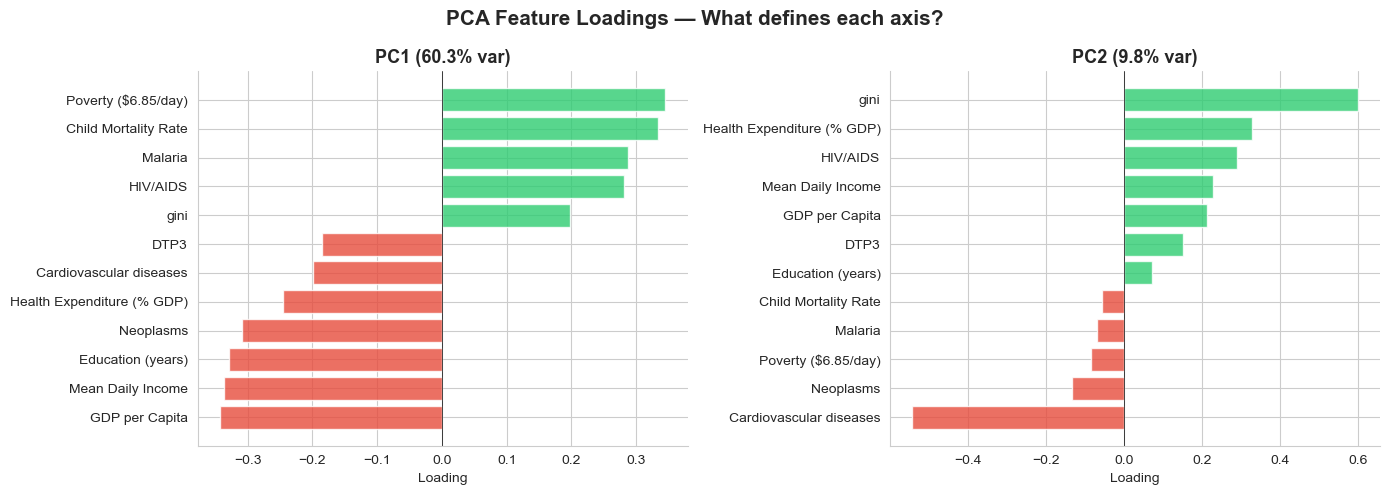

In [45]:
# === PCA LOADINGS ===

loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, pc in enumerate(['PC1', 'PC2']):
    ax = axes[i]
    sorted_loadings = loadings[pc].sort_values()
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sorted_loadings]
    ax.barh(sorted_loadings.index, sorted_loadings.values, color=colors, alpha=0.8)
    ax.set_title(f'{pc} ({pca.explained_variance_ratio_[i]*100:.1f}% var)', fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Loading')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('PCA Feature Loadings — What defines each axis?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# === CLUSTER MEANS TABLE ===

profile_cols  = features_f + [TARGET]
cluster_means = df_cluster_f.groupby('Cluster')[profile_cols].mean().round(2).T
cluster_means.columns = [f'Cluster {c}' for c in cluster_means.columns]
cluster_means['Global Mean'] = df_cluster_f[profile_cols].mean().round(2)

print('Cluster Means (all features + Life Expectancy):')
display(cluster_means)

Cluster Means (all features + Life Expectancy):


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Global Mean
Child Mortality Rate,6.02,1.90,0.40,0.65,2.18
Education (years),5.61,8.70,12.35,11.92,9.45
GDP per Capita,7.70,9.02,10.74,9.69,9.26
DTP3,80.94,88.89,94.49,90.72,88.89
Poverty ($6.85/day),84.96,36.58,1.38,12.38,34.19
Mean Daily Income,1.65,2.58,4.00,3.03,2.80
gini,0.43,0.39,0.32,0.32,0.37
Health Expenditure (% GDP),3.88,4.39,8.08,5.85,5.39
HIV/AIDS,3.93,1.48,0.49,0.85,1.64
Malaria,2.90,0.10,0.00,0.00,0.63


Countries per Cluster — Continent:


Continent,Africa,Asia,Europe,North America,Oceania,South America
Cluster,,,,,,
0,22,3,0,1,0,0
1,9,23,0,10,1,8
2,0,5,20,2,1,2
3,0,2,19,0,0,0


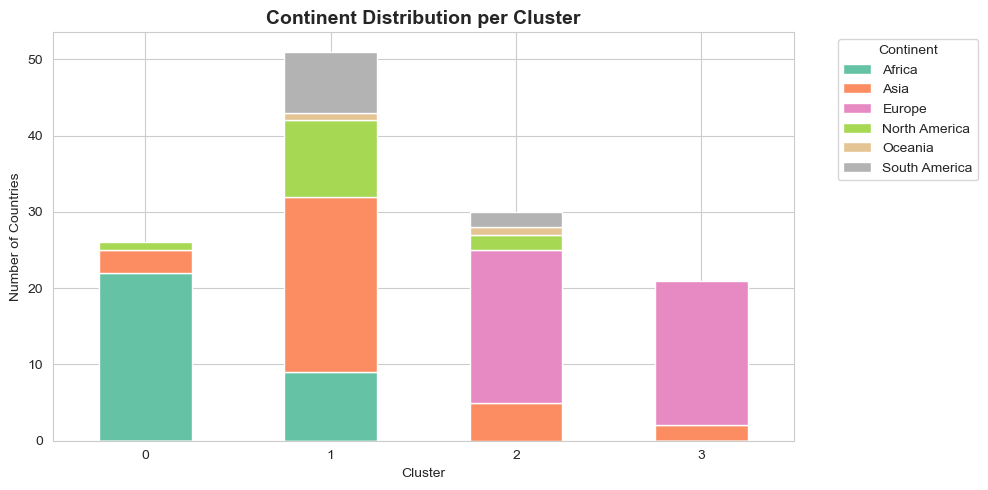

In [47]:
# === CONTINENT DISTRIBUTION PER CLUSTER ===

cluster_continent = pd.crosstab(df_cluster_f['Cluster'], df_cluster_f['Continent'])
print('Countries per Cluster — Continent:')
display(cluster_continent)

cluster_continent.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Continent Distribution per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Countries')
plt.xticks(rotation=0)
plt.legend(title='Continent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [48]:
# === RADAR CHART CLUSTER PROFILES ===

scaler_mm         = MinMaxScaler()
df_radar          = df_cluster_f.copy()
df_radar[features_f] = scaler_mm.fit_transform(df_radar[features_f])
cluster_radar_means  = df_radar.groupby('Cluster')[features_f].mean()

fig    = go.Figure()
colors = px.colors.qualitative.Set2

for cluster_id in sorted(cluster_radar_means.index):
    values  = cluster_radar_means.loc[cluster_id].tolist()
    values += [values[0]]  # close the polygon
    n       = (df_cluster_f['Cluster'] == cluster_id).sum()
    avg_le  = df_cluster_f[df_cluster_f['Cluster'] == cluster_id][TARGET].mean()
    fig.add_trace(go.Scatterpolar(
        r=values, theta=features_f + [features_f[0]],
        fill='toself',
        name=f'Cluster {cluster_id} (n={n}, LE={avg_le:.1f})',
        line=dict(color=colors[cluster_id % len(colors)]),
        opacity=0.6
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title='Cluster Profiles — Normalised Feature Comparison',
    width=800, height=600
)
fig.show()

---
# **4. Cluster Labelling**

Review the cluster means and radar chart above, then update `label_templates` to assign meaningful descriptive names.

In [87]:
# === CLUSTER LABELS ===
# Labels are ranked by Life Expectancy (rank 0 = highest LE cluster).
# Update label_templates after inspecting the cluster means above.

cluster_le_means = df_cluster_f.groupby('Cluster')[TARGET].mean().sort_values(ascending=False)

_k_actual = df_cluster_f['Cluster'].nunique()
if _k_actual != 4:
    import warnings
    warnings.warn(
        f'⚠️  label_templates is defined for k=4 but you have k={_k_actual}. '
        'Update label_templates to include all cluster ranks before proceeding.',
        UserWarning
    )

CLUSTER_LABELS = {
    0: 'High Infectious Burden',
    1: 'Middle-Income Transition', 
    2: 'High-Income Developed',
    3: 'Eastern European CVD Crisis',
}

df_cluster_f['Cluster_Label'] = df_cluster_f['Cluster'].map(CLUSTER_LABELS)

print(f'Clusters: ')
print(CLUSTER_LABELS)

Clusters: 
{0: 'High Infectious Burden', 1: 'Middle-Income Transition', 2: 'High-Income Developed', 3: 'Eastern European CVD Crisis'}


---
# **5. Outperformer & Underperformer Identification**

Within each cluster, countries share similar development conditions. We identify:
- **Outperformers**: Life Expectancy > cluster mean + 0.5 SD
- **Underperformers**: Life Expectancy < cluster mean − 0.5 SD

In [88]:
# === CLASSIFY PERFORMANCE ===

THRESHOLD_SD  = 0.5
cluster_stats = df_cluster_f.groupby('Cluster')[TARGET].agg(['mean', 'std'])

def classify_performance(row):
    c    = row['Cluster']
    le   = row[TARGET]
    mean = cluster_stats.loc[c, 'mean']
    std  = cluster_stats.loc[c, 'std']
    if le > mean + THRESHOLD_SD * std:
        return 'Outperformer'
    elif le < mean - THRESHOLD_SD * std:
        return 'Underperformer'
    return 'Average'

df_cluster_f['Performance'] = df_cluster_f.apply(classify_performance, axis=1)
df_cluster_f['LE_Residual'] = df_cluster_f.apply(
    lambda r: round(r[TARGET] - cluster_stats.loc[r['Cluster'], 'mean'], 2), axis=1
)

print('Performance distribution:')
print(f'Threshold: {THRESHOLD_SD}')
print(df_cluster_f['Performance'].value_counts().to_string())
print('\nPerformance by Cluster:')
display(pd.crosstab(df_cluster_f['Cluster_Label'], df_cluster_f['Performance']))

Performance distribution:
Threshold: 0.5
Performance
Average           47
Outperformer      46
Underperformer    35

Performance by Cluster:


Performance,Average,Outperformer,Underperformer
Cluster_Label,,,
Eastern European CVD Crisis,7,7,7
High Infectious Burden,8,10,8
High-Income Developed,15,11,4
Middle-Income Transition,17,18,16


In [89]:
# === VISUALISE: LE VS CLUSTER EXPECTED ===

fig = px.scatter(
    df_cluster_f,
    x='Cluster_Label', y=TARGET,
    color='Performance',
    hover_name='Country',
    hover_data=['Continent', 'LE_Residual'],
    color_discrete_map={
        'Outperformer':   '#2ecc71',
        'Average':        '#95a5a6',
        'Underperformer': '#e74c3c'
    },
    title='Life Expectancy by Cluster — Outperformers vs Underperformers',
    width=1000, height=600,
    category_orders={'Performance': ['Outperformer', 'Average', 'Underperformer']}
)

for cluster_id in sorted(df_cluster_f['Cluster'].unique()):
    label   = CLUSTER_LABELS[cluster_id]
    mean_le = cluster_stats.loc[cluster_id, 'mean']
    fig.add_shape(type='line', x0=label, x1=label,
                  y0=mean_le - 0.3, y1=mean_le + 0.3,
                  line=dict(color='black', width=3))

fig.update_traces(marker=dict(size=12, line=dict(width=1, color='white')))
fig.update_layout(xaxis_title='Cluster', yaxis_title='Life Expectancy (years)', font=dict(size=13))
fig.show()

In [90]:
# === TOP OUTPERFORMERS & UNDERPERFORMERS ===

print('🟢 TOP OUTPERFORMERS (beating their cluster peers):')
print('='*80)
outperformers = df_cluster_f[df_cluster_f['Performance'] == 'Outperformer'].sort_values('LE_Residual', ascending=False)
for _, row in outperformers[:10].iterrows():
    print(f"  {row['Country']:25s} | Cluster: {row['Cluster_Label']:35s} | LE: {row[TARGET]:.1f} | Residual: +{row['LE_Residual']:.1f} yrs")

print(f'\n🔴 TOP UNDERPERFORMERS (lagging behind their cluster peers):')
print('='*80)
underperformers = df_cluster_f[df_cluster_f['Performance'] == 'Underperformer'].sort_values('LE_Residual')
for _, row in underperformers[:10].iterrows():
    print(f"  {row['Country']:25s} | Cluster: {row['Cluster_Label']:35s} | LE: {row[TARGET]:.1f} | Residual: {row['LE_Residual']:.1f} yrs")

🟢 TOP OUTPERFORMERS (beating their cluster peers):
  Chile                     | Cluster: Middle-Income Transition            | LE: 80.0 | Residual: +6.8 yrs
  Costa Rica                | Cluster: Middle-Income Transition            | LE: 79.9 | Residual: +6.7 yrs
  Maldives                  | Cluster: Middle-Income Transition            | LE: 79.4 | Residual: +6.2 yrs
  Greece                    | Cluster: Eastern European CVD Crisis         | LE: 81.1 | Residual: +5.5 yrs
  Panama                    | Cluster: Middle-Income Transition            | LE: 78.0 | Residual: +4.8 yrs
  China                     | Cluster: Middle-Income Transition            | LE: 77.7 | Residual: +4.5 yrs
  Lebanon                   | Cluster: Middle-Income Transition            | LE: 77.4 | Residual: +4.3 yrs
  Mauritania                | Cluster: High Infectious Burden              | LE: 67.3 | Residual: +4.2 yrs
  Yemen                     | Cluster: High Infectious Burden              | LE: 67.0 | Resid

---
# **6. Gap Analysis — What Outperformers Do Differently**

In [91]:
# === GAP ANALYSIS PER CLUSTER ===

gap_results = {}

for cluster_id in sorted(df_cluster_f['Cluster'].unique()):
    label = CLUSTER_LABELS[cluster_id]
    out   = df_cluster_f[(df_cluster_f['Cluster'] == cluster_id) & (df_cluster_f['Performance'] == 'Outperformer')]
    under = df_cluster_f[(df_cluster_f['Cluster'] == cluster_id) & (df_cluster_f['Performance'] == 'Underperformer')]

    if len(out) == 0 or len(under) == 0:
        print(f'\n⚠️  Cluster {cluster_id} ({label}): not enough outperformers or underperformers.')
        continue

    print(f"\n{'='*80}")
    print(f'CLUSTER {cluster_id}: {label}')
    print(f"  Outperformers ({len(out)}): {', '.join(out['Country'].tolist())}")
    print(f"  Underperformers ({len(under)}): {', '.join(under['Country'].tolist())}")
    print(f"{'-'*80}")

    gaps = []
    for feat in features_f:
        out_mean   = out[feat].mean()
        under_mean = under[feat].mean()
        diff       = out_mean - under_mean
        c_std      = df_cluster_f[df_cluster_f['Cluster'] == cluster_id][feat].std()
        rel_diff   = diff / c_std if c_std > 0 else 0
        gaps.append({
            'Feature':            feat,
            'Outperformer_Mean':  out_mean,
            'Underperformer_Mean': under_mean,
            'Gap':                diff,
            'Relative_Gap_SD':    rel_diff
        })

    df_gap = pd.DataFrame(gaps).sort_values('Relative_Gap_SD', key=abs, ascending=False)
    gap_results[cluster_id] = df_gap

    for _, row in df_gap.head(10).iterrows():
        direction = '↑' if row['Relative_Gap_SD'] > 0 else '↓'
        print(f"  {direction} {row['Feature']:35s} | Out: {row['Outperformer_Mean']:10.2f} | Under: {row['Underperformer_Mean']:10.2f} | Gap: {row['Relative_Gap_SD']:+.2f} SD")


CLUSTER 0: High Infectious Burden
  Outperformers (10): Ethiopia, Malawi, Mauritania, Myanmar, Pakistan, Rwanda, South Africa, Tanzania, Uganda, Yemen
  Underperformers (8): Cameroon, Eswatini, Lesotho, Liberia, Mozambique, Niger, Sierra Leone, Zimbabwe
--------------------------------------------------------------------------------
  ↓ Child Mortality Rate                | Out:       4.72 | Under:       7.87 | Gap: -1.50 SD
  ↓ HIV/AIDS                            | Out:       3.19 | Under:       4.53 | Gap: -1.02 SD
  ↓ gini                                | Out:       0.40 | Under:       0.44 | Gap: -0.51 SD
  ↓ Malaria                             | Out:       2.49 | Under:       3.25 | Gap: -0.50 SD
  ↑ Neoplasms                           | Out:      64.74 | Under:      57.47 | Gap: +0.40 SD
  ↓ Health Expenditure (% GDP)          | Out:       3.70 | Under:       4.37 | Gap: -0.33 SD
  ↑ GDP per Capita                      | Out:       7.75 | Under:       7.51 | Gap: +0.33 SD
  ↑ Ca

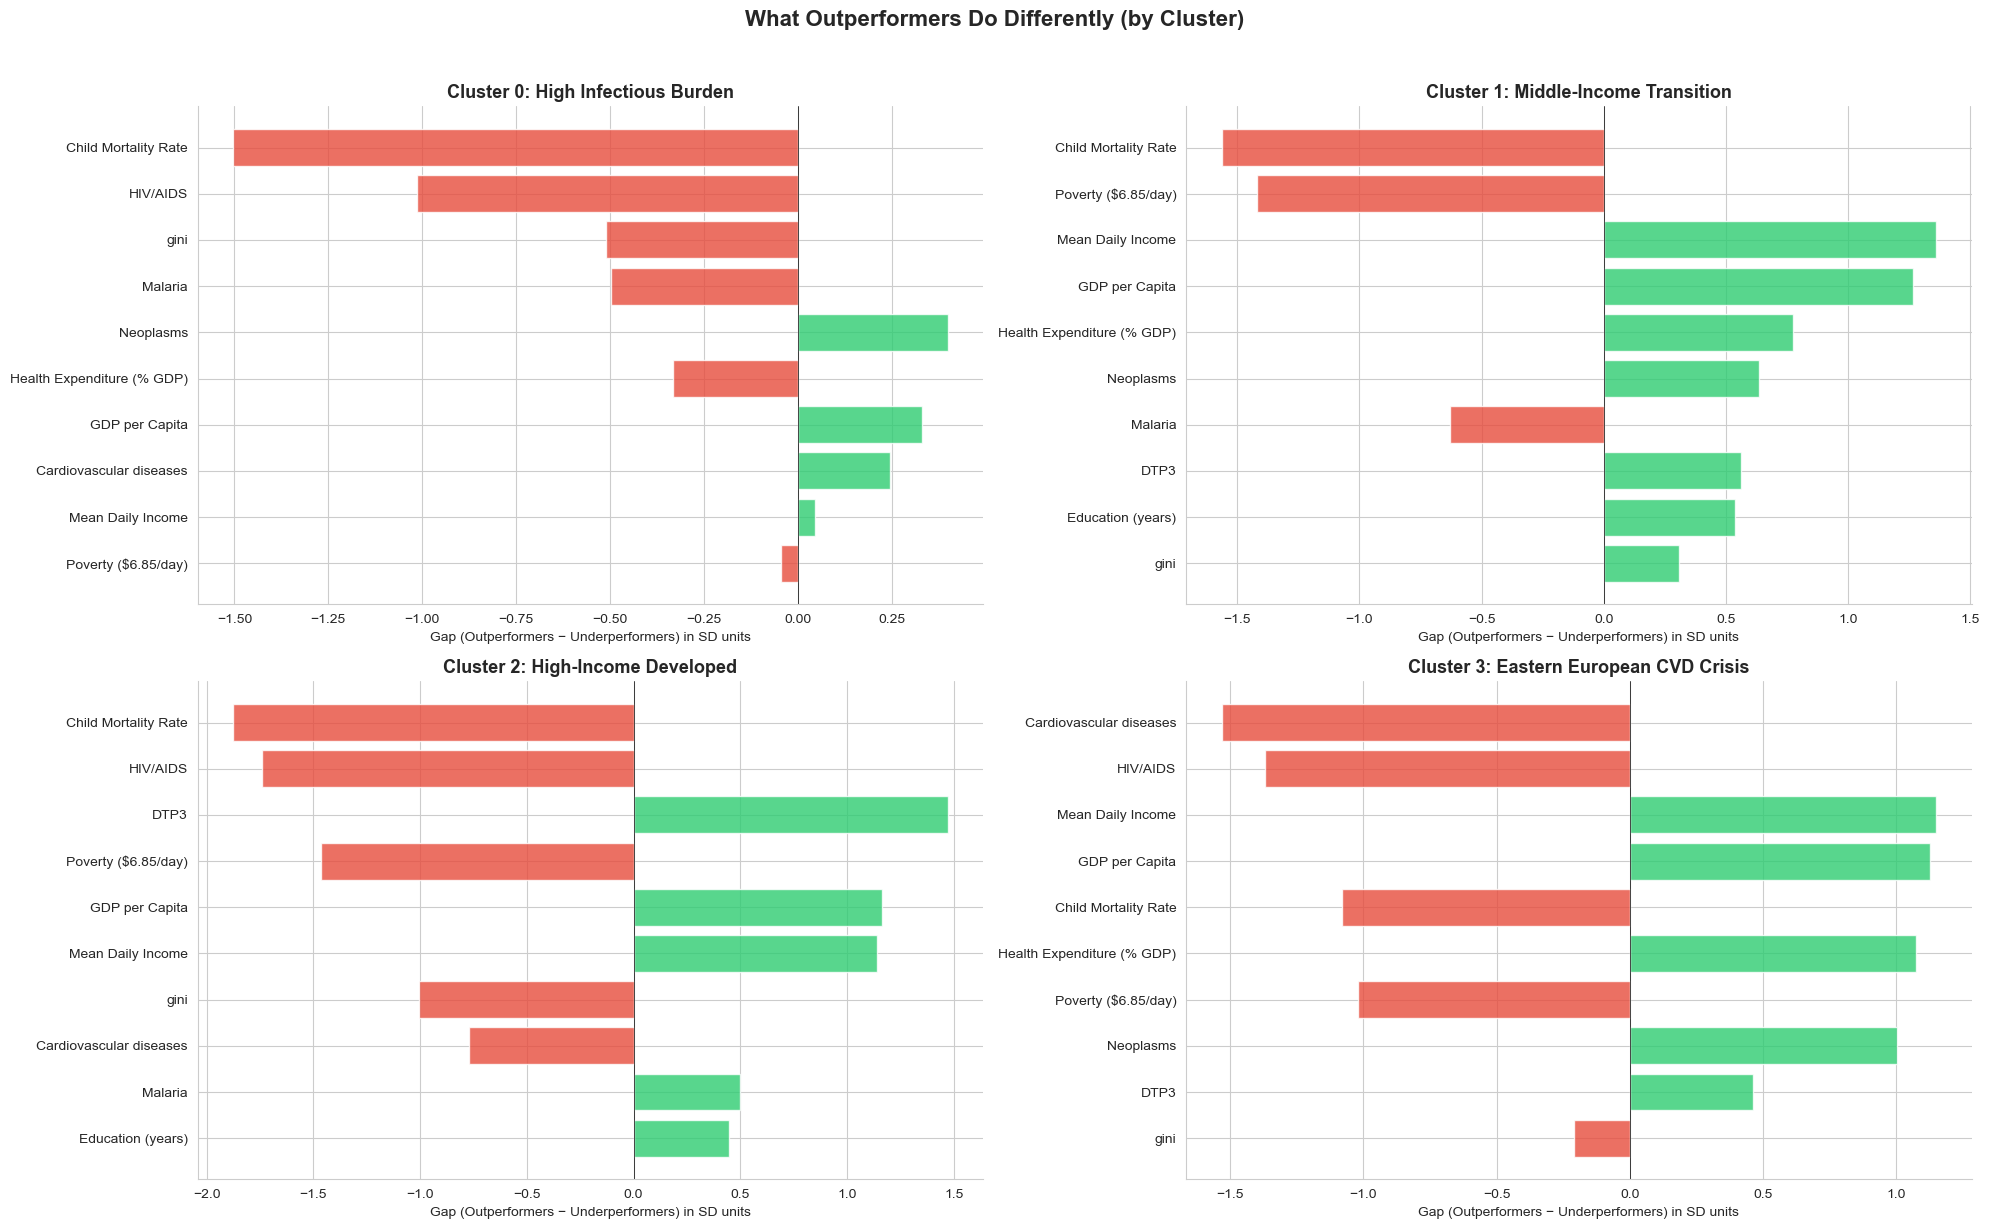

In [92]:
# === VISUALISE GAPS ===

clusters_with_gaps = list(gap_results.keys())
n_plots = len(clusters_with_gaps)

if n_plots > 0:
    n_cols = min(2, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10 * n_cols, 6 * n_rows))
    axes = [axes] if n_plots == 1 else axes.flatten()

    for idx, cluster_id in enumerate(clusters_with_gaps):
        ax     = axes[idx]
        df_gap = gap_results[cluster_id].head(10)
        colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_gap['Relative_Gap_SD']]
        ax.barh(df_gap['Feature'], df_gap['Relative_Gap_SD'], color=colors, alpha=0.8)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.set_xlabel('Gap (Outperformers − Underperformers) in SD units')
        ax.set_title(f'Cluster {cluster_id}: {CLUSTER_LABELS[cluster_id]}', fontsize=13, fontweight='bold')
        ax.invert_yaxis()
        ax.spines[['top', 'right']].set_visible(False)

    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('What Outperformers Do Differently (by Cluster)', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No clusters had both outperformers and underperformers.')

---
# **7. Country Diagnostic Tool — "Find My Peers"**

Given a country, this tool:
1. Identifies its cluster and peer group
2. Shows its performance relative to peers
3. Identifies which features are dragging it down vs lifting it up
4. Recommends specific improvement areas based on outperformer benchmarks

In [93]:
def country_diagnostic(country_name, df_cluster, feature_names, target, cluster_labels, gap_results):
    """
    Generate a full diagnostic report for a specific country.

    Note: features that were log-transformed during clustering (GDP per Capita,
    HIV/AIDS, Malaria, Mean Daily Income) are displayed in their original scale
    because values come from df_profile, not the scaled X matrix.
    """
    country_row = df_cluster[df_cluster['Country'] == country_name]
    if len(country_row) == 0:
        matches = df_cluster[df_cluster['Country'].str.contains(country_name, case=False, na=False)]
        if len(matches) == 0:
            print(f"❌ Country '{country_name}' not found.")
            print(f'Available: {sorted(df_cluster["Country"].tolist())}')
            return
        country_row = matches.iloc[[0]]
        country_name = country_row['Country'].values[0]
        print(f'(Matched to: {country_name})')

    row             = country_row.iloc[0]
    cluster_id      = row['Cluster']
    cluster_label   = cluster_labels[cluster_id]
    peers           = df_cluster[df_cluster['Cluster'] == cluster_id].copy()
    peer_outperformers = peers[(peers['Performance'] == 'Outperformer') & 
                                (peers['Country'] != country_name)].copy()

    print('\n' + '='*80)
    print(f'  COUNTRY DIAGNOSTIC REPORT: {country_name.upper()}')
    print('-'*80)
    print(f'\n📍 Continent: {row["Continent"]}')
    print(f'📊 Cluster: {cluster_id} — {cluster_label}')
    print(f'📈 Life Expectancy: {row[target]:.1f} years')
    print(f'   Cluster Average: {peers[target].mean():.1f} years')
    print(f'   Residual: {row["LE_Residual"]:+.1f} years  |  Performance: {row["Performance"]}')

    rank = (peers[target] > row[target]).sum() + 1
    print(f'\n🏆 Rank within peer group: {rank}/{len(peers)}')

    print(f'\n📋 FEATURE COMPARISON vs Cluster Peers:')
    print('-'*80)

    lower_is_better = ['Child Mortality Rate', 'Suicide', 'Homicide', 
                        'Poverty', 'gini', 'Cardiovascular', 'HIV', 
                        'Malaria', 'Tuberculosis']
    
    comparisons = []
    for feat in feature_names:
        peer_mean = peers[feat].mean()
        peer_std  = peers[feat].std()
        z         = (row[feat] - peer_mean) / peer_std if peer_std > 0 else 0
        comparisons.append({'Feature': feat, 'Country': row[feat], 'Peer_Mean': peer_mean, 'Z_Score': z})

    df_comp = pd.DataFrame(comparisons).sort_values('Z_Score')
    for _, comp in df_comp.iterrows():
        is_neg = any(neg in comp['Feature'] for neg in lower_is_better)
        z      = comp['Z_Score']
        icon   = ('🟢' if (is_neg and z < -0.5) or (not is_neg and z > 0.5) else
                  '🔴' if (is_neg and z > 0.5)  or (not is_neg and z < -0.5) else '🟡')
        print(f'  {icon} {comp["Feature"]:35s} | {comp["Country"]:12.2f} | Peer Avg: {comp["Peer_Mean"]:12.2f} | Z: {z:+.2f}')

    print(f'\n💡 KEY RECOMMENDATIONS:')
    print('-'*80)
    if len(peer_outperformers) > 0:
        print(f'   Benchmarking against outperformers: {", ".join(peer_outperformers["Country"].tolist())}\n')
        recs = []
        for feat in feature_names:
            out_mean   = peer_outperformers[feat].mean()
            diff       = out_mean - row[feat]
            peer_std   = peers[feat].std()
            rel_diff   = diff / peer_std if peer_std > 0 else 0
            is_neg     = any(neg in feat for neg in lower_is_better)
            improvement = -rel_diff if is_neg else rel_diff
            if improvement > 0.3:
                recs.append({'Feature': feat, 'Current': row[feat],
                             'Outperformer_Target': out_mean, 'Gap_SD': improvement})
        for i, rec in enumerate(sorted(recs, key=lambda x: x['Gap_SD'], reverse=True)[:5], 1):
            print(f"   {i}. Improve {rec['Feature']}:")
            print(f"      Current: {rec['Current']:.2f} → Target: {rec['Outperformer_Target']:.2f}")
            print(f"      Gap: {rec['Gap_SD']:.2f} SD below outperformer benchmark\n")
    else:
        print('   No outperformers in this cluster for benchmarking.')

    print(f'\n🌍 PEER COUNTRIES TO STUDY:')
    print('-'*80)
    better_peers = peers[peers[target] > row[target]].sort_values(target, ascending=False)
    for _, peer in better_peers.head(5).iterrows():
        print(f"  {peer['Country']:25s} | LE: {peer[target]:.1f} (+{peer[target] - row[target]:.1f} vs {country_name}) | {peer['Continent']}")

    print('\n' + '='*80)
    return df_comp

In [94]:
CLUSTER_LABELS

{0: 'High Infectious Burden',
 1: 'Middle-Income Transition',
 2: 'High-Income Developed',
 3: 'Eastern European CVD Crisis'}

In [95]:
# === RUN DIAGNOSTIC FOR A SAMPLE COUNTRY ===
# Change the country name to diagnose any country in your dataset

diagnostic = country_diagnostic(
    country_name='Colombia',        # <-- Change this
    df_cluster=df_cluster_f,
    feature_names=features_f,
    target=TARGET,
    cluster_labels=CLUSTER_LABELS,
    gap_results=gap_results
)


  COUNTRY DIAGNOSTIC REPORT: COLOMBIA
--------------------------------------------------------------------------------

📍 Continent: South America
📊 Cluster: 1 — Middle-Income Transition
📈 Life Expectancy: 76.0 years
   Cluster Average: 73.2 years
   Residual: +2.8 years  |  Performance: Outperformer

🏆 Rank within peer group: 12/51

📋 FEATURE COMPARISON vs Cluster Peers:
--------------------------------------------------------------------------------
  🟢 Cardiovascular diseases             |       143.71 | Peer Avg:       196.70 | Z: -0.78
  🟢 Child Mortality Rate                |         1.37 | Peer Avg:         1.90 | Z: -0.65
  🟡 Education (years)                   |         8.64 | Peer Avg:         8.70 | Z: -0.03
  🟡 Poverty ($6.85/day)                 |        36.80 | Peer Avg:        36.58 | Z: +0.01
  🟡 Neoplasms                           |        97.48 | Peer Avg:        96.16 | Z: +0.04
  🟡 DTP3                                |        89.56 | Peer Avg:        88.89 | Z: +0.

In [96]:
# === RUN DIAGNOSTIC FOR ANOTHER COUNTRY ===

diagnostic2 = country_diagnostic(
    country_name='Estonia',          # <-- Change this
    df_cluster=df_cluster_f,
    feature_names=features_f,
    target=TARGET,
    cluster_labels=CLUSTER_LABELS,
    gap_results=gap_results
)


  COUNTRY DIAGNOSTIC REPORT: ESTONIA
--------------------------------------------------------------------------------

📍 Continent: Europe
📊 Cluster: 3 — Eastern European CVD Crisis
📈 Life Expectancy: 78.3 years
   Cluster Average: 75.6 years
   Residual: +2.7 years  |  Performance: Outperformer

🏆 Rank within peer group: 3/21

📋 FEATURE COMPARISON vs Cluster Peers:
--------------------------------------------------------------------------------
  🟢 Child Mortality Rate                |         0.26 | Peer Avg:         0.65 | Z: -1.23
  🟢 Poverty ($6.85/day)                 |         1.48 | Peer Avg:        12.38 | Z: -0.74
  🟢 Cardiovascular diseases             |       569.17 | Peer Avg:       662.59 | Z: -0.54
  🟡 gini                                |         0.31 | Peer Avg:         0.32 | Z: -0.26
  🟡 Malaria                             |         0.00 | Peer Avg:         0.00 | Z: +0.00
  🟡 DTP3                                |        91.44 | Peer Avg:        90.72 | Z: +0.08
  🟡

---
# **8. Export Cluster Results**

In [97]:
export_cols = [
    'Country', 'Continent', 'Cluster', 'Cluster_Label',
    'Performance', 'LE_Residual', TARGET
] + features_f

df_export = df_cluster_f[export_cols].sort_values(
    ['Cluster', TARGET], ascending=[True, False]
)

df_export.to_csv('Phase_B_docs/df_clustered_countries.csv', index=False)

print(f'✅ Exported: df_clustered_countries.csv  {df_export.shape}')
print(f'\n📊 Summary:')
print(f'   Total countries  : {len(df_export)}')
print(f'   Clusters         : {df_export["Cluster"].nunique()}')
print(f'   Outperformers    : {(df_export["Performance"] == "Outperformer").sum()}')
print(f'   Underperformers  : {(df_export["Performance"] == "Underperformer").sum()}')
print(f'   Average          : {(df_export["Performance"] == "Average").sum()}')

✅ Exported: df_clustered_countries.csv  (128, 19)

📊 Summary:
   Total countries  : 128
   Clusters         : 4
   Outperformers    : 46
   Underperformers  : 35
   Average          : 47


---
## **~Summary & Key Findings~**

*(Complete after running the notebook)*

### Outputs
| File | Description |
|------|-------------|
| `df_clustered_countries.csv` | Country clusters, labels, performance classification, feature profiles |
| `gap_analysis_by_cluster.png` | What outperformers do differently per cluster |

### Key outputs
1. **Country clusters** based on development profiles (economic, health, education, inequality)
2. **Performance classification** — outperformers vs underperformers within each peer group
3. **Gap analysis** — specific factors distinguishing outperformers per cluster
4. **Country Diagnostic Tool** — reusable function for any country in the dataset

### ⚠️ Re-run after Phase C
The feature set used here (`candidates_correlations.json`) is correlation-driven. After Phase C training, re-run this notebook replacing the candidates with the **top SHAP features** from the model to ensure peer groups are grounded in genuinely predictive variables.

### Next: Phase C — `framework_c_modeling.ipynb`
Inputs: `candidates_correlations.json`, `lag_correlation_summary.csv`, `partial_correlations_gdp_control.csv`, `df_merged_all_imputed.csv`, `df_clustered_countries.csv`